In [73]:
import numpy as np
import pandas as pd
import re

In [74]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [75]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [76]:
df.duplicated().sum()

121

In [77]:
df.head(1)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Central Square Mall', 'Golf Course Ext Road', 'Badshahpur Sohna Rd Hwy', 'ORCHIDS The International School', 'Sushant University', 'Marengo Asia Hospitals', 'Indira Gandhi Intl Airport', 'Gurgaon Railway Station']",Situated in prime location of sector 61 on golf course ext road,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"


##### 1. areaWithType

In [78]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
135,0.56,800.0,Carpet area: 800 (74.32 sq.m.)
2277,2.25,1400.0,Plot area 2160(200.67 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.)
2340,1.38,1150.0,Super Built up area 1573(146.14 sq.m.)Built Up area: 1350 sq.ft. (125.42 sq.m.)Carpet area: 1150 sq.ft. (106.84 sq.m.)
1580,2.80,1828.0,Built Up area: 1828 (169.83 sq.m.)
1682,2.65,1582.0,Carpet area: 124


In [79]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [80]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [81]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [82]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [83]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
329,6.21,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
371,5.00,flat,6500.0,Carpet area: 5200 (483.1 sq.m.),NaN,NaN,5200.0
971,2.20,flat,1966.0,Super Built up area 2100(195.1 sq.m.),2100.0,NaN,NaN
3401,1.90,flat,2727.0,Super Built up area 2727(253.35 sq.m.)Carpet area: 2300 sq.ft. (213.68 sq.m.),2727.0,NaN,2300.0
1586,0.81,flat,1308.0,Super Built up area 1300(120.77 sq.m.),1300.0,NaN,NaN


In [84]:
df.duplicated().sum()

121

In [85]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [86]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.6,house,2160.0,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
15,6.0,house,190.0,Plot area 190(17.65 sq.m.)Carpet area: 1600 sq.ft. (148.64 sq.m.),NaN,NaN,1600.0
19,11.3,house,4500.0,Plot area 500(418.06 sq.m.)Built Up area: 480 sq.yards (401.34 sq.m.)Carpet area: 460 sq.yards (384.62 sq.m.),NaN,480.0,460.0
28,2.9,house,1557.0,Plot area 173(144.65 sq.m.)Built Up area: 1415 sq.yards (1183.12 sq.m.)Carpet area: 1350 sq.yards (1128.77 sq.m.),NaN,1415.0,1350.0
39,11.0,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN


In [87]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
description               0
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [88]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [89]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.6,house,2160.0,Plot area 240(200.67 sq.m.),NaN,NaN,NaN
39,11.0,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
43,4.5,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
44,4.0,house,6001.0,Plot area 6000(557.42 sq.m.),NaN,NaN,NaN
45,8.1,house,2295.0,Plot area 255(213.21 sq.m.),NaN,NaN,NaN


In [90]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [91]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [92]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [93]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.60,house,2160.0,Plot area 240(200.67 sq.m.),NaN,240.00,NaN
39,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
43,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
44,4.00,house,6001.0,Plot area 6000(557.42 sq.m.),NaN,6000.00,NaN
45,8.10,house,2295.0,Plot area 255(213.21 sq.m.),NaN,255.00,NaN
57,8.00,house,300.0,Plot area 300(27.87 sq.m.),NaN,300.00,NaN
59,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
71,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
78,2.50,house,3542.0,Plot area 3400(315.87 sq.m.),NaN,3400.00,NaN
80,0.60,house,540.0,Plot area 60(50.17 sq.m.),NaN,60.00,NaN


In [94]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [95]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [96]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
9,4.60,house,2160.0,Plot area 240(200.67 sq.m.),NaN,2160.00,NaN
39,11.00,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
43,4.50,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
44,4.00,house,6001.0,Plot area 6000(557.42 sq.m.),NaN,6000.00,NaN
45,8.10,house,2295.0,Plot area 255(213.21 sq.m.),NaN,2295.00,NaN
57,8.00,house,300.0,Plot area 300(27.87 sq.m.),NaN,300.00,NaN
59,8.50,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
71,9.00,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
78,2.50,house,3542.0,Plot area 3400(315.87 sq.m.),NaN,3400.00,NaN
80,0.60,house,540.0,Plot area 60(50.17 sq.m.),NaN,540.00,NaN


In [97]:
df.update(all_nan_df)

In [98]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
description               0
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [99]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Central Square Mall', 'Golf Course Ext Road', 'Badshahpur Sohna Rd Hwy', 'ORCHIDS The International School', 'Sushant University', 'Marengo Asia Hospitals', 'Indira Gandhi Intl Airport', 'Gurgaon Railway Station']",Situated in prime location of sector 61 on golf course ext road,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']",NaN,1150.0,NaN
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,4,3+,servant room,2.0,North-East,0 to 1 Year Old,"['Sapphire 83', 'NH 48', 'Cambridge Montessori', 'Miracles Apollo Hospital', 'IGI Airport', 'Garhi Harsaru Junction', 'Hyatt Regency']","A north facing 4 bhk resale flat is available in the promising locality of sector-82a, gurgaon. It is a ready to move in spacious flat and is located on the 2nd floor. Every single detail of the flat is carefully designed. This feng shui/vaastu compliant property offers quality specifications such as club house/communi.","['1 Water Purifier', '1 Fridge', '8 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '1 Stove', '1 Modular Kitchen', '1 Chimney', '6 AC', '1 Curtains', '4 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Light', 'No TV']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2606.0,NaN,1800.0
2,flat,bptp astaire gardens,sector 70a,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,not available,1.0,North-East,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","On gurgaon spr, good potential as this area is coming up in big way all amenities are available near by, over all very pleasant and calm place to live.","['6 Fan', '1 Exhaust Fan', '3 Geyser', '20 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,1900.0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 858 sq.ft. (79.71 sq.m.),2,2,2,not available,14.0,North-West,undefined,NaN,"Club house, mini theater, squash court, swimming pool, banquet hall, cafataaria, indoor games room, gymnasium, swimming pool, banquet hall, caferaria shapoorji pallonji joyville 

##### 2.additionalRoom

In [100]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
study room,servant room                            99
store room                                         99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
servant room,

In [101]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [102]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
3451,"study room,servant room",1,1,0,0,0
1543,store room,0,0,1,0,0
2870,not available,0,0,0,0,0
1165,servant room,0,1,0,0,0
2594,others,0,0,0,0,1


In [103]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,2.0,NaN,Dec 2023,"['Sector 55-56 Metro station', 'Bestech Central Square Mall', 'Golf Course Ext Road', 'Badshahpur Sohna Rd Hwy', 'ORCHIDS The International School', 'Sushant University', 'Marengo Asia Hospitals', 'Indira Gandhi Intl Airport', 'Gurgaon Railway Station']",Situated in prime location of sector 61 on golf course ext road,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']",NaN,1150.0,NaN,1,0,0,0,0
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,4,3+,servant room,2.0,North-East,0 to 1 Year Old,"['Sapphire 83', 'NH 48', 'Cambridge Montessori', 'Miracles Apollo Hospital', 'IGI Airport', 'Garhi Harsaru Junction', 'Hyatt Regency']","A north facing 4 bhk resale flat is available in the promising locality of sector-82a, gurgaon. It is a ready to move in spacious flat and is located on the 2nd floor. Every single detail of the flat is carefully designed. This feng shui/vaastu compliant property offers quality specifications such as club house/communi.","['1 Water Purifier', '1 Fridge', '8 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '1 Stove', '1 Modular Kitchen', '1 Chimney', '6 AC', '1 Curtains', '4 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Light', 'No TV']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2606.0,NaN,1800.0,0,1,0,0,0
2,flat,bptp astaire gardens,sector 70a,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,not available,1.0,North-East,1 to 5 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","On gurgaon spr, good potential as this area is coming up in big way all amenities are available near by, over all very pleasant and calm place to live.","['6 Fan', '1 Exhaust Fan', '3 Geyser', '20 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,1900.0,0,0,0,0,0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 858 sq.ft. (79.71 sq.m.),2,2,2,not available,14.0,North-West,undefined,NaN,"Club house, mini theater, squash court, swimming pool, banquet hall, cafataaria, indoor games r

##### 3.agePossession

In [104]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Aug 2023                 7
Dec 2025                 7
Jun 2024                 7
Nov 2023                 5
By 2025                  4
Oct 2023                 4
Sep 2023                 4
Jul 2024                 4
Aug 2024                 4
Jan 2025                 3
Feb 2024                 3
Nov 2024                 3
May 2024                 3
Aug 2025                 2
Sep 2025                 2
By 2027                  2
Apr 2026                 2
Jul 2027                 2
Mar 2025                 2
Jan 2026                 2
Oct 2025                 2
Jun 2027      

In [105]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [106]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [107]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [108]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,2.0,NaN,Under Construction,"['Sector 55-56 Metro station', 'Bestech Central Square Mall', 'Golf Course Ext Road', 'Badshahpur Sohna Rd Hwy', 'ORCHIDS The International School', 'Sushant University', 'Marengo Asia Hospitals', 'Indira Gandhi Intl Airport', 'Gurgaon Railway Station']",Situated in prime location of sector 61 on golf course ext road,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']",NaN,1150.0,NaN,1,0,0,0,0
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,4,3+,servant room,2.0,North-East,New Property,"['Sapphire 83', 'NH 48', 'Cambridge Montessori', 'Miracles Apollo Hospital', 'IGI Airport', 'Garhi Harsaru Junction', 'Hyatt Regency']","A north facing 4 bhk resale flat is available in the promising locality of sector-82a, gurgaon. It is a ready to move in spacious flat and is located on the 2nd floor. Every single detail of the flat is carefully designed. This feng shui/vaastu compliant property offers quality specifications such as club house/communi.","['1 Water Purifier', '1 Fridge', '8 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '1 Stove', '1 Modular Kitchen', '1 Chimney', '6 AC', '1 Curtains', '4 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Light', 'No TV']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2606.0,NaN,1800.0,0,1,0,0,0
2,flat,bptp astaire gardens,sector 70a,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,not available,1.0,North-East,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","On gurgaon spr, good potential as this area is coming up in big way all amenities are available near by, over all very pleasant and calm place to live.","['6 Fan', '1 Exhaust Fan', '3 Geyser', '20 Light', '6 AC', '1 Chimney', '1 Modular Kitchen', '3 Wardrobe', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']",NaN,NaN,1900.0,0,0,0,0,0
3,flat,shapoorji pallonji joyville gurugram,sector 102,0.95,10383.0,915.0,Built Up area: 915 (85.01 sq.m.)Carpet area: 858 sq.ft. (79.71 sq.m.),2,2,2,not available,14.0,North-West,Undefined,NaN,"Club house, mini theater, squash court, swimming pool, banquet hall, cafataaria, indoor g

##### 4.furnishDetails

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3803 entries, 0 to 3802
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3803 non-null   object 
 1   society              3802 non-null   object 
 2   sector               3803 non-null   object 
 3   price                3785 non-null   float64
 4   price_per_sqft       3785 non-null   float64
 5   area                 3785 non-null   float64
 6   areaWithType         3803 non-null   object 
 7   bedRoom              3803 non-null   int64  
 8   bathroom             3803 non-null   int64  
 9   balcony              3803 non-null   object 
 10  additionalRoom       3803 non-null   object 
 11  floorNum             3784 non-null   float64
 12  facing               2698 non-null   object 
 13  agePossession        3803 non-null   object 
 14  nearbyLocations      3626 non-null   object 
 15  description          3803 non-null   o

##### 4.furnishDetails

In [110]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2792,"['5 Fan', '6 Light', '4 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
441,"['3 Fan', '1 Exhaust Fan', '3 Geyser', '7 Light', '1 Chimney', '2 Wardrobe', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",NaN
2173,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '3 Geyser', '12 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1749,"['1 Fan', '1 Light', '2 Wardrobe', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Waste Disposal']"
3749,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '7 Light', '1 Curtains', '1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center', 'Water softening plant']"


In [111]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [112]:
furnishings_df.shape

(3803, 19)

In [113]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_13912\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [114]:
furnishings_df.sample(5)

,TV,Stove,Chimney,Modular Kitchen,Microwave,Fridge,Water Purifier,Fan,Bed,Dining Table,Sofa,AC,Geyser,Light,Wardrobe,Exhaust Fan,Curtains,Washing Machine
243,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2354,0,1,1,1,0,0,0,8,0,0,0,5,0,10,3,1,1,1
2347,0,0,1,1,0,0,0,0,0,0,0,5,0,15,0,0,0,0
3240,0,0,0,0,0,0,0,9,0,0,0,0,0,0,5,0,0,0
291,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [115]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [116]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [117]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

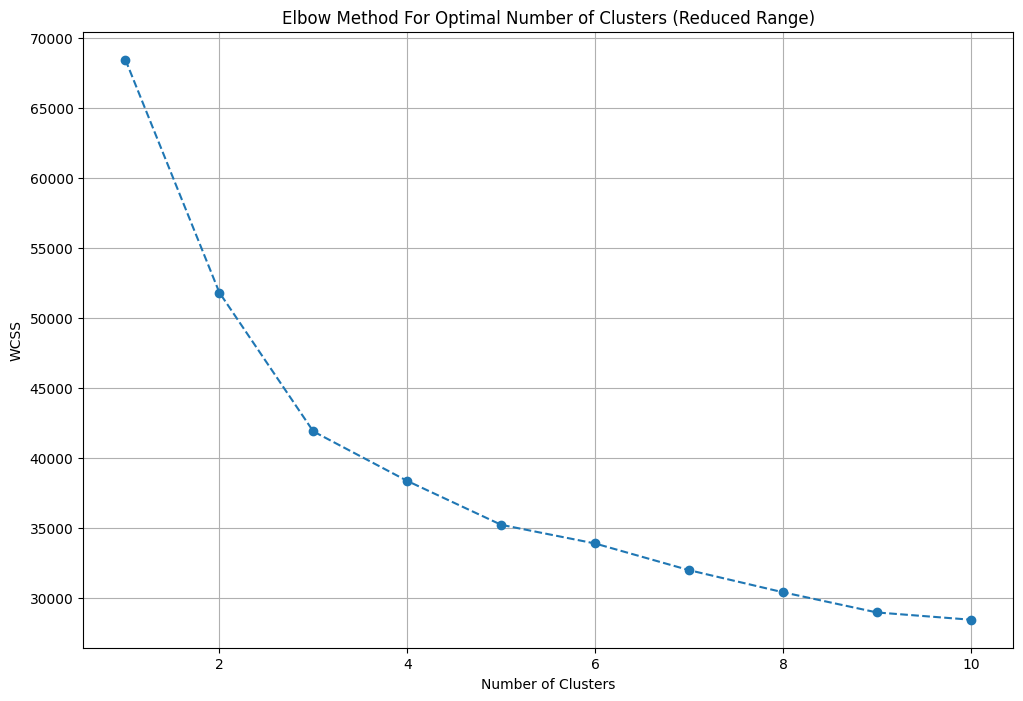

In [118]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [119]:
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

cluster_assignments = kmeans.predict(scaled_data)

In [120]:
df = df.iloc[:,:-18]

In [121]:
df['furnishing_type'] = cluster_assignments

In [122]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
533,[],1
1742,"['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '6 Light', '1 Modular Kitchen', '1 Chimney', 'No AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Geyser', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
2451,NaN,1
247,"['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '12 Light', '4 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']",0
750,"['4 Fan', '1 Exhaust Fan', '4 Geyser', '4 Light', '4 AC', '1 Chimney', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0


##### 5.features

In [123]:
df[['society','features']].sample(5)

,society,features
3158,pareena coban residences,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
469,smriti apartment,"['Power Back-up', 'Feng Shui / Vaastu Compliant', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Rain Water Harvesting']"
1656,central park flower valley,"['Feng Shui / Vaastu Compliant', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Swimming Pool', 'Separate entry for servant room', 'Park', 'Bank Attached Property', 'Visitor Parking', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center']"
1299,zara aavaas,NaN
3260,bptp visionnaire,"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Water purifier', 'Centrally Air Conditioned', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"


In [124]:
df['features'].isnull().sum()

635

In [125]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [126]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [127]:
temp_df = df[df['features'].isnull()]

In [128]:
temp_df.shape

(635, 27)

In [129]:
x = temp_df.merge(app_df,left_on='society', right_on='PropertyName', how='left')['TopFacilities']

In [130]:
df.loc[temp_df.index,'features'] = x.values

In [131]:
df['features'].isnull().sum()

481

In [132]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [133]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [134]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
1034,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
486,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
723,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
1785,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
641,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0


In [135]:
features_binary_df.shape

(3803, 130)

In [136]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

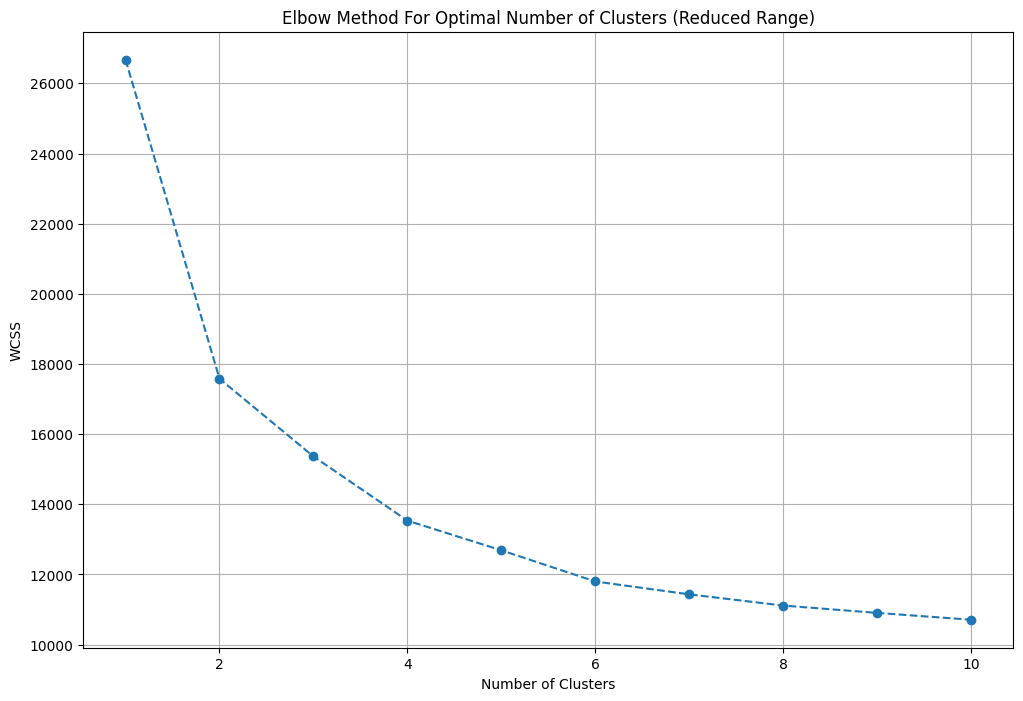

In [137]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [138]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [139]:
df['luxury_score'] = luxury_score

In [140]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,smart world orchard,sector 61,1.41,12250.0,1151.0,Built Up area: 1150 (106.84 sq.m.),2,2,2,study room,2.0,NaN,Under Construction,"['Sector 55-56 Metro station', 'Bestech Central Square Mall', 'Golf Course Ext Road', 'Badshahpur Sohna Rd Hwy', 'ORCHIDS The International School', 'Sushant University', 'Marengo Asia Hospitals', 'Indira Gandhi Intl Airport', 'Gurgaon Railway Station']",Situated in prime location of sector 61 on golf course ext road,[],"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']",NaN,1150.0,NaN,1,0,0,0,0,1,"[Security / Fire Alarm, Intercom Facility, Lift(s), Maintenance Staff, Water Storage, Visitor Parking, Swimming Pool, Park, Security Personnel, Shopping Centre, Fitness Centre / GYM, Club house / Community Center, Water softening plant]",76
1,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),4,4,3+,servant room,2.0,North-East,New Property,"['Sapphire 83', 'NH 48', 'Cambridge Montessori', 'Miracles Apollo Hospital', 'IGI Airport', 'Garhi Harsaru Junction', 'Hyatt Regency']","A north facing 4 bhk resale flat is available in the promising locality of sector-82a, gurgaon. It is a ready to move in spacious flat and is located on the 2nd floor. Every single detail of the flat is carefully designed. This feng shui/vaastu compliant property offers quality specifications such as club house/communi.","['1 Water Purifier', '1 Fridge', '8 Fan', '1 Exhaust Fan', '1 Dining Table', '6 Geyser', '1 Stove', '1 Modular Kitchen', '1 Chimney', '6 AC', '1 Curtains', '4 Wardrobe', '1 Sofa', '1 Microwave', '1 Washing Machine', 'No Bed', 'No Light', 'No TV']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",2606.0,NaN,1800.0,0,1,0,0,0,2,"[Centrally Air Conditioned, Water purifier, Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connectivity, Recently Renovated, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Water softening plant, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",174
2,flat,bptp astaire gardens,sector 70a,1.70,8947.0,1900.0,Carpet area: 1900 (176.52 sq.m.),4,3,3,not available,1.0,North-East,Relatively New,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hy

In [141]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [142]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,description,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
928,flat,bestech park view grand spa,sector 81,4.50,10714.0,4200.0,Super Built up area 4200(390.19 sq.m.),4,6,3+,17.0,NaN,Relatively New,"The biggest apartment of new gurgaon in sector 81 prime location, connected with nh-48 & dwarka expressway.Elite class residents like ceo, cfo, pilots etc\nSpacious 4bhk,family lounge, servant room.Pool facing unit.",4200.0,NaN,NaN,0,1,0,0,0,0,44
2574,flat,hsiidc sidco aravali,manesar,0.91,3516.0,2588.0,Super Built up area 2588(240.43 sq.m.)Built Up area: 1900 sq.ft. (176.52 sq.m.),3,3,3+,8.0,East,Moderately Old,Arawali sidco good property imt manesar \nNear etc ..........................................................................\n Additional details :Piped gas facility is available in the property.\nThe apartment has borings water supply.\nDaily needs shopping could be done within the society premises to make the stay convinent.\nFull power backup is available.\nThere is also a separate washroom for domestic help.\nThe society has dedicated security guards for every tower.,2588.0,1900.0,NaN,0,1,0,0,0,1,23
719,house,international city by sobha phase 2,sector 109,8.48,23556.0,3600.0,Plot area 400(334.45 sq.m.),4,6,3+,3.0,North-East,New Property,"400 sqyd plot , 4bhk sobha villa with lift provision and vrv installed. Luxury segment villa in sobha community with all world class amenities and club house . Independent villa with lush grennery and infrastructure. For details and visit connect on given details",NaN,3600.0,NaN,1,1,1,1,0,1,153
1656,house,central park flower valley,sector 33,1.15,9349.0,1230.0,Plot area 1737(161.37 sq.m.)Built Up area: 1400 sq.ft. (130.06 sq.m.)Carpet area: 1230 sq.ft. (114.27 sq.m.),2,2,3,2.0,North,Relatively New,The flat is very good location and 100% power backup club gym and swimming pool the floor is brand new the cricket ground and near by school hospital and market the near by g d goinka school and medanta hospital etc.,NaN,1400.0,1230.0,1,0,0,0,0,0,71
2529,house,uppal southend,sector 49,3.75,25562.0,1467.0,Built Up area: 163 (136.29 sq.m.),6,6,3+,3.0,East,Moderately Old,Uppal southend sector 49.Gated society. Near by market.School.Temple etc.163sq.Yd plot size.6bhk .Park facing east facing.100power back up.,NaN,163.0,NaN,1,0,0,0,0,0,26


In [143]:
df.shape

(3803, 24)

In [144]:
df.to_csv('gurgaon_properties_cleaned_v2.csv', index=False)